In [102]:
# We Want to peak at the data first and get total chars
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Total characters: {len(text)}")
print(text[:200])

Total characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [103]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import torch, math

print("imports work!")


imports work!


In [104]:
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]"])
tokenizer.train(['input.txt'], trainer=trainer)

In [105]:
# encode text
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

encoded = tokenizer.encode(text)

token_ids = encoded.ids
tokens_tensor = torch.tensor(token_ids, dtype=torch.long)

print("Total tokens:", len(token_ids))
print("Tensor shape:", tokens_tensor.shape)
print("First 20 IDs:", tokens_tensor[:20])

Total tokens: 447512
Tensor shape: torch.Size([447512])
First 20 IDs: tensor([404,  14,  90,  46,  63,  72,   9, 393, 280, 113, 297,  98, 107, 421,
         43, 135, 128,   5, 392,  78])


In [148]:
seq_len = 50
inputs = []
targets = []

# your loop here
for i in range(0, len(tokens_tensor) - seq_len, 10):
    inputs.append(tokens_tensor[i : i + seq_len])
    targets.append(tokens_tensor[i+1 : i + seq_len + 1])

print(f"Number of sequences: {len(inputs)}")
print(f"Input shape: {torch.stack(inputs).shape}")

Number of sequences: 44747
Input shape: torch.Size([44747, 50])


In [149]:
split = int(0.8*( len(inputs)))

train_inputs = inputs[:split]
train_targets = targets[:split]
val_inputs = inputs[split:]
val_targets = targets[split:]

print(f"sizes: {len(train_inputs)} {len(train_targets)} {len(val_inputs)} {len(val_targets)} ")

sizes: 35797 35797 8950 8950 


In [150]:
from torch.utils.data import Dataset, DataLoader

class ShakespeareDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.stack(inputs)
        self.targets = torch.stack(targets)

    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

In [151]:
train_dataset = ShakespeareDataset(train_inputs, train_targets)
val_dataset = ShakespeareDataset(val_inputs, val_targets)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# verify one batch
x, y = next(iter(train_loader))
print("Input batch shape:", x.shape)
print("Target batch shape:", y.shape)

Input batch shape: torch.Size([32, 50])
Target batch shape: torch.Size([32, 50])


In [152]:
import torch.nn as nn

vocab_size = 500
embed_dim = 64

token_embedding = nn.Embedding(vocab_size, embed_dim)

# verify
x, y = next(iter(train_loader))
embedded = token_embedding(x)
print(embedded.shape)

torch.Size([32, 50, 64])


In [153]:
def positional_encoding(seq_len, embed_dim):
    pe = torch.zeros(seq_len, embed_dim)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
    pe[:, 0::2] = torch.sin(position * div_term) # Even indices: 0, 2, 4...
    pe[:, 1::2] = torch.cos(position * div_term) # Odd indices: 1, 3, 5...
    return pe.unsqueeze(0)

pe = positional_encoding(50, 64)
print(pe.shape)

x_embed = embedded + pe
print(x_embed.shape)

torch.Size([1, 50, 64])
torch.Size([32, 50, 64])


In [154]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.W_Q = nn.Linear(embed_dim, embed_dim)
        self.W_K = nn.Linear(embed_dim, embed_dim)
        self.W_V = nn.Linear(embed_dim, embed_dim)
        self.scale = math.sqrt(embed_dim)
    
    def forward(self, x):
        # Step 1: compute Q, K, V
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # Step 2: compute scores = Q @ K.transpose(-2, -1) / scale 
        scores = Q @ K.transpose(-2, -1) / self.scale
        seq_len = x.size(1)
        # add causal mask
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        # Step 3: softmax over scores
        weights = torch.softmax(scores, dim=-1)

        # Step 4: output = weights @ V
        output = weights @ V

        return output, weights

# test
attn = SelfAttention(64)
out, weights = attn(x_embed)  # unpack tuple
print(out.shape)

torch.Size([32, 50, 64])


In [155]:
class RMSNorm(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(embed_dim))
    
    def forward(self, x):
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + 1e-8)
        return self.scale * x / rms

In [156]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, ff_dim):
        super().__init__()
        self.attention = SelfAttention(embed_dim)
        self.norm1 = RMSNorm(embed_dim)
        self.norm2 = RMSNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
    
    def forward(self, x):
        attn_out, attn_weights = self.attention(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x, attn_weights


In [157]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, ff_dim, num_blocks, seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, ff_dim) for _ in range(num_blocks)])
        self.norm = RMSNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.seq_len = seq_len
    
    def forward(self, x):
        x = self.embedding(x)
        x = x + positional_encoding(self.seq_len, x.size(-1))
        all_weights = []
        for block in self.blocks:
            x, w = block(x)
            all_weights.append(w)
        x = self.norm(x)
        x = self.head(x)
        return x, all_weights


model = TinyTransformer(vocab_size=500, embed_dim=64, ff_dim=128, num_blocks=2, seq_len=50)
out, all_weights = model(x)
print(out.shape)  # should be [32, 50, 500]

torch.Size([32, 50, 500])


In [158]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for x, y in loader:
        optimizer.zero_grad()
        out,_ = model(x)
        loss = criterion(out.view(-1, 500), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


In [159]:
def validation_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            out,_ = model(x)
            loss = criterion(out.view(-1, 500), y.view(-1))
            total_loss += loss.item()
        return total_loss / len(loader)


In [160]:
torch.manual_seed(42)

model = TinyTransformer(vocab_size=500, embed_dim=64, ff_dim=128, num_blocks=2, seq_len=50)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
num_epochs = 30

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader)
    val_loss = validation_epoch(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}: train={train_loss:.4f}, val={val_loss:.4f}")

Epoch 1/30: train=4.4465, val=4.4131
Epoch 2/30: train=3.8569, val=4.3222
Epoch 3/30: train=3.6968, val=4.2932
Epoch 4/30: train=3.6066, val=4.2587
Epoch 5/30: train=3.5455, val=4.2286
Epoch 6/30: train=3.5014, val=4.2234
Epoch 7/30: train=3.4675, val=4.2223
Epoch 8/30: train=3.4406, val=4.2220
Epoch 9/30: train=3.4180, val=4.2162
Epoch 10/30: train=3.3983, val=4.2117
Epoch 11/30: train=3.3818, val=4.2287
Epoch 12/30: train=3.3677, val=4.2164
Epoch 13/30: train=3.3546, val=4.2235
Epoch 14/30: train=3.3430, val=4.2183
Epoch 15/30: train=3.3330, val=4.2303
Epoch 16/30: train=3.3233, val=4.2138
Epoch 17/30: train=3.3141, val=4.2247
Epoch 18/30: train=3.3055, val=4.2414
Epoch 19/30: train=3.2980, val=4.2338
Epoch 20/30: train=3.2912, val=4.2215
Epoch 21/30: train=3.2849, val=4.2216
Epoch 22/30: train=3.2780, val=4.2449
Epoch 23/30: train=3.2724, val=4.2375
Epoch 24/30: train=3.2664, val=4.2350
Epoch 25/30: train=3.2613, val=4.2456
Epoch 26/30: train=3.2558, val=4.2431
Epoch 27/30: train=3.

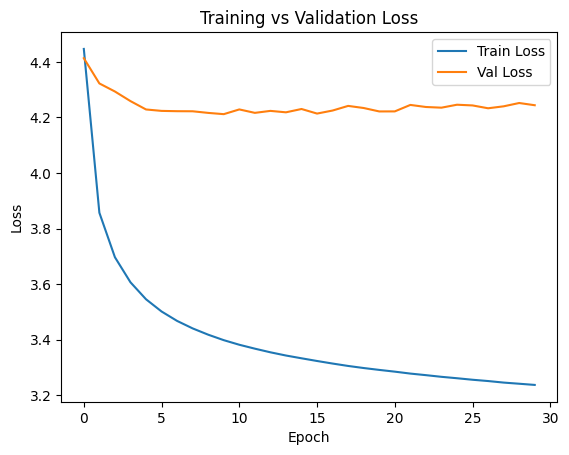

In [161]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [162]:
import math
ppl = math.exp(val_losses[-1])
print(f"Final Validation Perplexity: {ppl:.2f}")

Final Validation Perplexity: 69.67


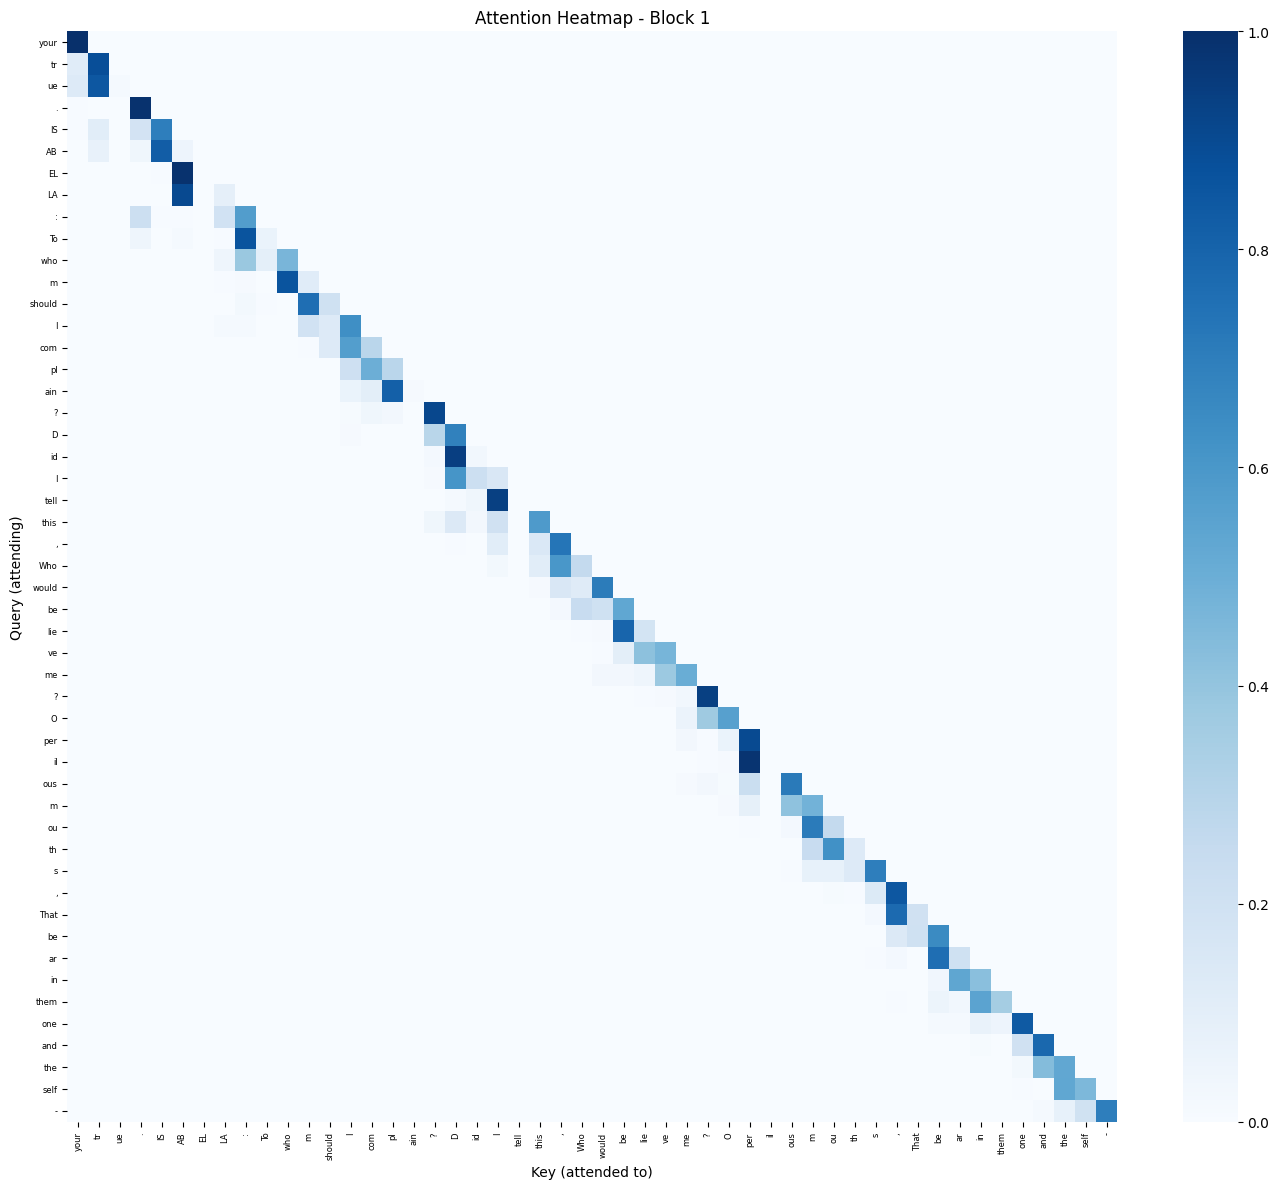

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
with torch.no_grad():
    sample_x = val_dataset.inputs[0].unsqueeze(0)  # [1, 50]
    _, all_weights = model(sample_x)

# Get attention weights from block 0, sequence 0
attn = all_weights[0][0].numpy()  # [50, 50]

# Get token strings for labels
sample_ids = sample_x[0].tolist()
tokens = [tokenizer.id_to_token(i) for i in sample_ids]

plt.figure(figsize=(14, 12))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
plt.title('Attention Heatmap - Block 1')
plt.xlabel('Key (attended to)')
plt.ylabel('Query (attending)')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()


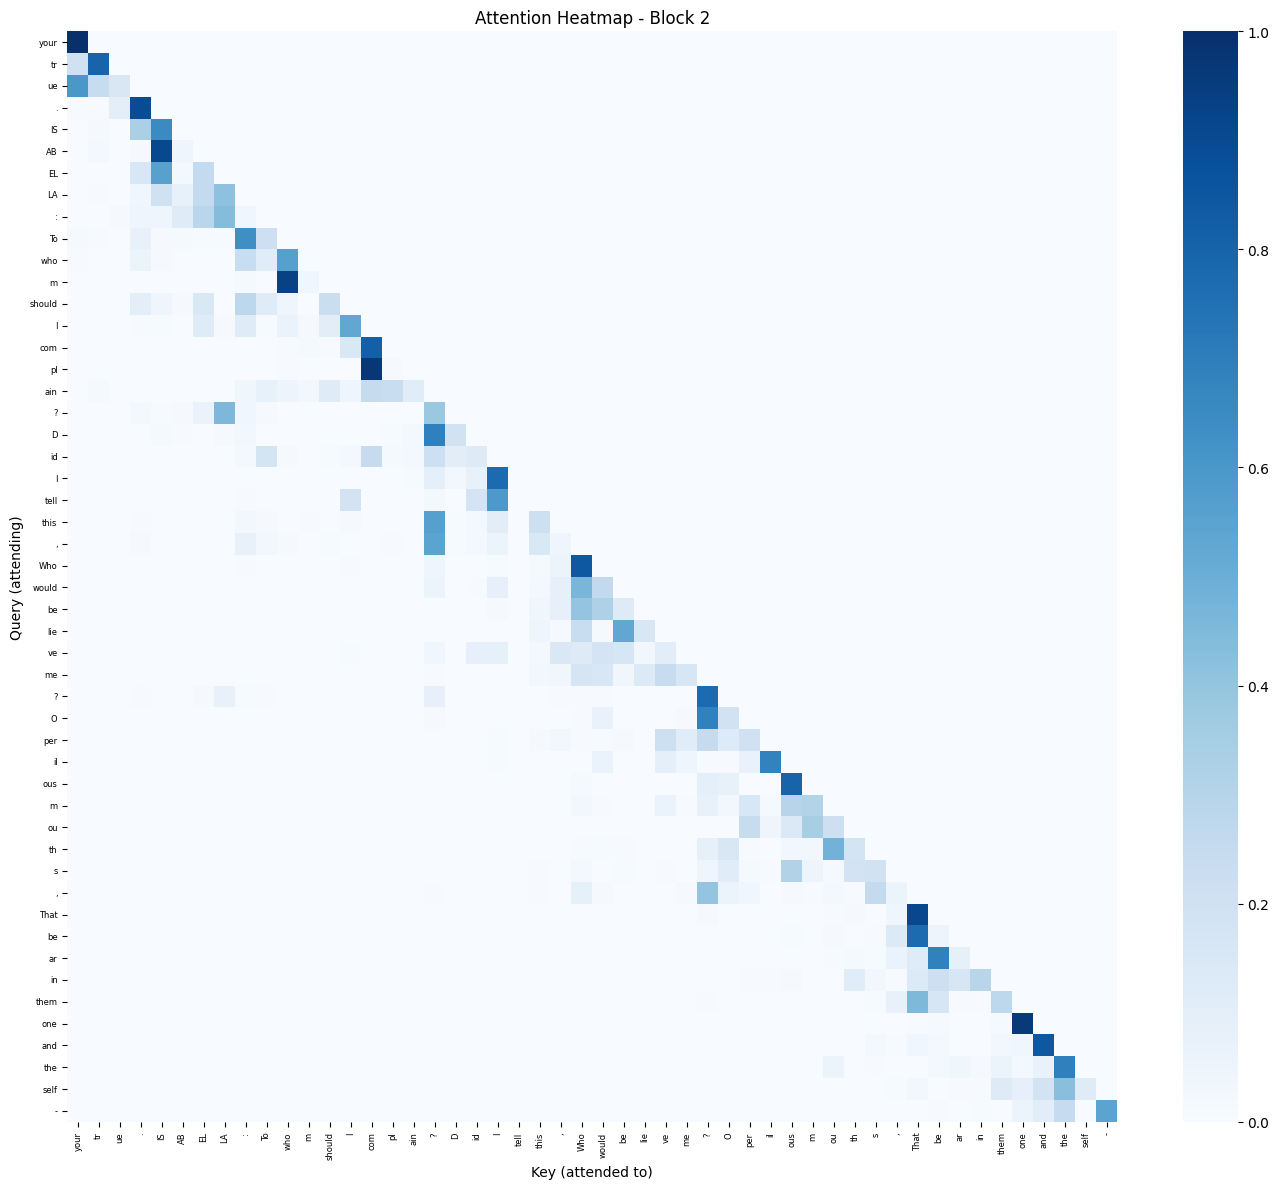

In [164]:
attn2 = all_weights[1][0].numpy()  # Block 2

plt.figure(figsize=(14, 12))
sns.heatmap(attn2, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
plt.title('Attention Heatmap - Block 2')
plt.xlabel('Key (attended to)')
plt.ylabel('Query (attending)')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()


In [165]:
import torch.nn.functional as F
def generate(model, tokenizer, prompt, max_new_tokens=50, seq_len=50):
    model.eval()
    tokens = tokenizer.encode(prompt).ids
    # pad to seq_len with zeros if shorter
    if len(tokens) < seq_len:
        tokens = [0] * (seq_len - len(tokens)) + tokens
    tokens = torch.tensor(tokens).unsqueeze(0)  # [1, 50]
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = tokens[:, -seq_len:]
            logits, _ = model(x)
            # temperature sampling
            probs = F.softmax(logits[0, -1, :] / 0.8, dim=-1)  # temperature=0.8
            next_token = torch.multinomial(probs, num_samples=1).item()
            tokens = torch.cat([tokens, torch.tensor([[next_token]])], dim=1)
    
    output_ids = tokens[0].tolist()
    return tokenizer.decode(output_ids)

print(generate(model, tokenizer, "To be or not"))


To be or not I . RO S I R S E P R INC E : W hi le an I . To heart is a ble to stand ' d Rome o p in ion where in of this de ed . RO M E O : Come , let them on
